# Algorytm Scale-Invariant Feature Transform (SIFT)
_Kurs "Analiza danych obrazowych i multimedialnych" 26L_

- **Zespół 4:** Cong Minh Vu, Mateusz Szulc, Szymon Ochnio, Mateusz Kwiatkowski
- **Data realizacji:** maj 2026

### Opis algorytmu

Algorytm **SIFT (Scale-Invariant Feature Transform)** służy do detekcji i szczegółowego opisu lokalnych cech obrazu, co pozwala na rozpoznawanie i dopasowywanie tych samych obiektów na różnych zdjęciach.

W wyniku swojego działania wyznacza on punkty charakterystyczne obrazu (key points), które cechują się:
- niewrażliwością na jednorodne zmiany skali obrazu i jego rotację,
- częściową niewrażliwością na zmiany oświetlenia i położeicnie kamery (perspektywę).

Proces wykrywania punktów charakterystycznych składa się z kilku etapów:
1. **Detekcja potencjalnych punktów charakterystycznych** - obraz jest wielokrotnie rozmywany i skalowany. Badanie różnic między rozmyciami pozwala na wykrycie potencjalnych lokalnych cech w różnych skalach. Zapewnia to niewrażliwość na jednorodne zmiany skali obrazu.
2. **Lokalizacja punktów charakterystycznych** - wyznacza się dokładną lokalizację punktów w dziedzinie subpixeli, a następnie odrzuca punkty znajdujące się na krawędziach lub takie o niskim kontraście.
3. **Przypisanie orientacji** - przypisuje punktom dominujący kierunek gradientu ich otoczenia. Pozwala to na zapewnienie niewrażliwości na rotację obrazu.
4. **Budowa deskryptorów** - opisuje punkty poprzez charakterystyczne wektory 128 cech utworzone poprzez lokalne zastosowanie metody HOG w ich otoczeniu. Pozwala to na zapewnienie wysokiej rozróżnialności punktów i uprosza proces poszukiwania odpowiadających punktów między obrazami.

Algorytm SIFT posiada liczne zastosowania i jest powszechnie wykorzystywany m.in. do: rozpoznawania obiektów, śledzenia ruchu, wirtualnej rzeczywistości (AR), tworzenia panoram (stitching), modelowania 3D.

**Przydatne źródła:**
- [Oficjalny tutorial OpenCV dla metody SIFT](https://docs.opencv.org/4.x/da/df5/tutorial_py_sift_intro.html)
- [Artykuł oryginalny: David G. Lowe (2004) "Distinctive Image Features from Scale-Invariant Keypoints"](https://www.cs.ubc.ca/~lowe/papers/ijcv04.pdf)
- [Opis algorytmu SIFT (Wikipedia)](https://en.wikipedia.org/wiki/Scale-invariant_feature_transform)
- [Repozytorium kodu OpenCV z przykładami](https://github.com/opencv/opencv)

### Przedstawienie algorytmu SIFT - krok po kroku (uproszczone)

Poniżej zostało przedstawione działanie algorytmu SIFT krok po kroku z odpowiednimi wizualizacjami. Pewne kroki algorytmu zostały uproszczone w celu zapewnienia lepszego zrozumienia jego działania.

#### Krok 0. Importy i funkcje pomocnicze

In [ ]:
%pip install opencv-python matplotlib numpy ipywidgets scipy

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def show_img(img: np.ndarray, title="Obraz", cmap='gray', figsize=(10, 8)):
    plt.figure(figsize=figsize)

    if img.ndim == 3:  # Konwersja BGR do RGB dla Matplotlib
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap)

    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.show()

#### Krok 1. Wczytywanie obrazu

Wczytujemy obraz, na których będziemy pracować. Przekształcamy go w skalę szarości, ponieważ SIFT operuje na zmianach jasności, wobec czego kolor jest niepotrzebny. Dla łatwiejszych obliczeń wartości jasności pikseli zostają znormalizowane.

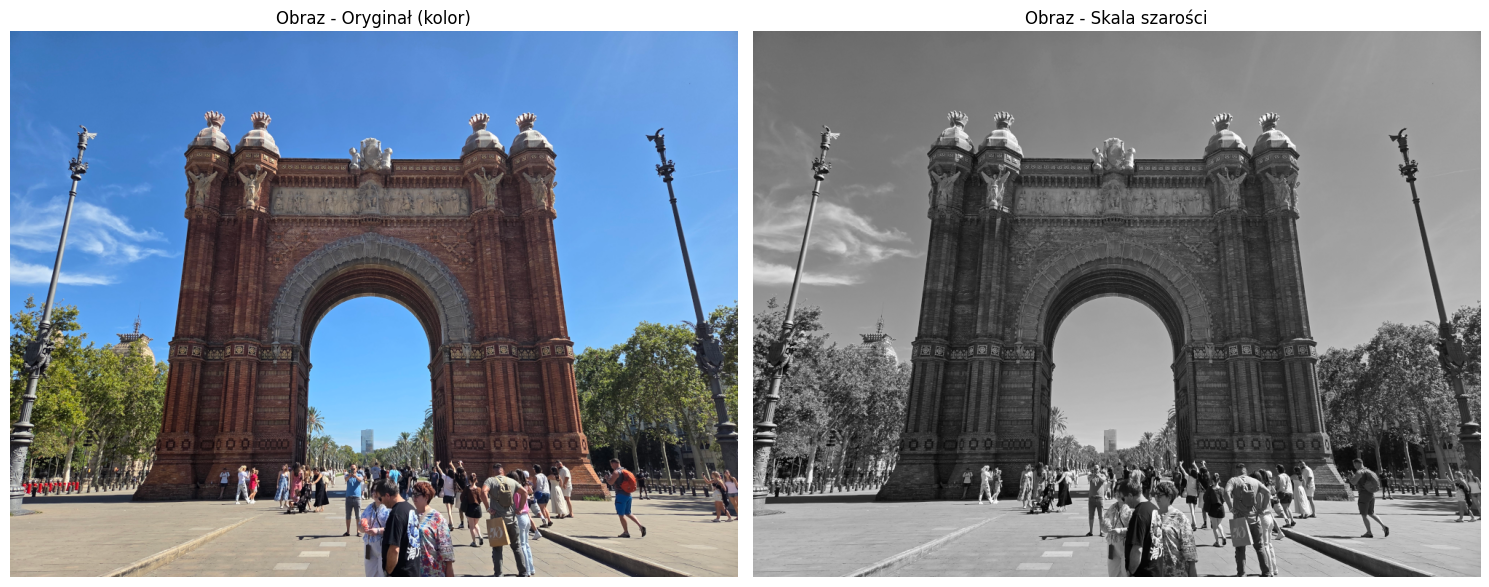

In [3]:
# USTAW NA ŚCIEŻKĘ WŁASNEGO OBRAZU
IMAGE_PATH = 'data/ref.png'

image = cv2.imread(IMAGE_PATH)

if image is None:
    raise "Błąd: Nie znaleziono obrazu!"

image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0

fig, ax = plt.subplots(1, 2, figsize=(15, 12))
ax[0].imshow(image[:, :, ::-1])
ax[0].set_title("Obraz - Oryginał (kolor)")
ax[0].axis('off')
ax[1].imshow(image_gray, cmap='gray')
ax[1].set_title("Obraz - Skala szarości")
ax[1].axis('off')

plt.tight_layout()
plt.show()

#### Krok 2. Przekształcenie w przestrzeni skali (piramida Gaussjanów)

Obrazy często zawierają obiekty w znacząco różnych rozmiarach, wobec czego przetwarzanie ich w jednakowy sposób mogłoby być nieefektywne - w tym celu stosuje się przetwarzanie w wielu skalach. Algorythm SIFT dokonuje tego poprzez kaskadowe rozmywanie obrazu filtrem Gaussa, co symuluje oddalanie się od obiektu.

Jako że rosnące rozmywanie obrazu powoduje utratę szczegółów, przetwarzanie obrazu w tym samym rozmiarze powoduje wyłącznie zbędne koszty obliczeniowe. W tym celu tworzy się tzw. **oktawy** - zestawy obrazów o jednakowym rozmiarze, ale stale rosnącym poziomie rozmycia.

Współczynnik rozmycia ($\sigma$) rośnie geometrycznie z każdym krokiem o stałą wartość $k$. Możemy zauważyć, jak wraz z rosnącym rozmyciem znikają drobne detale, a zostają tylko główne, "silne" cechy kształtu.

_Ważne: dla uproszczenia algorytmu zostanie wyznaczona wyłącznie jedna oktawa_

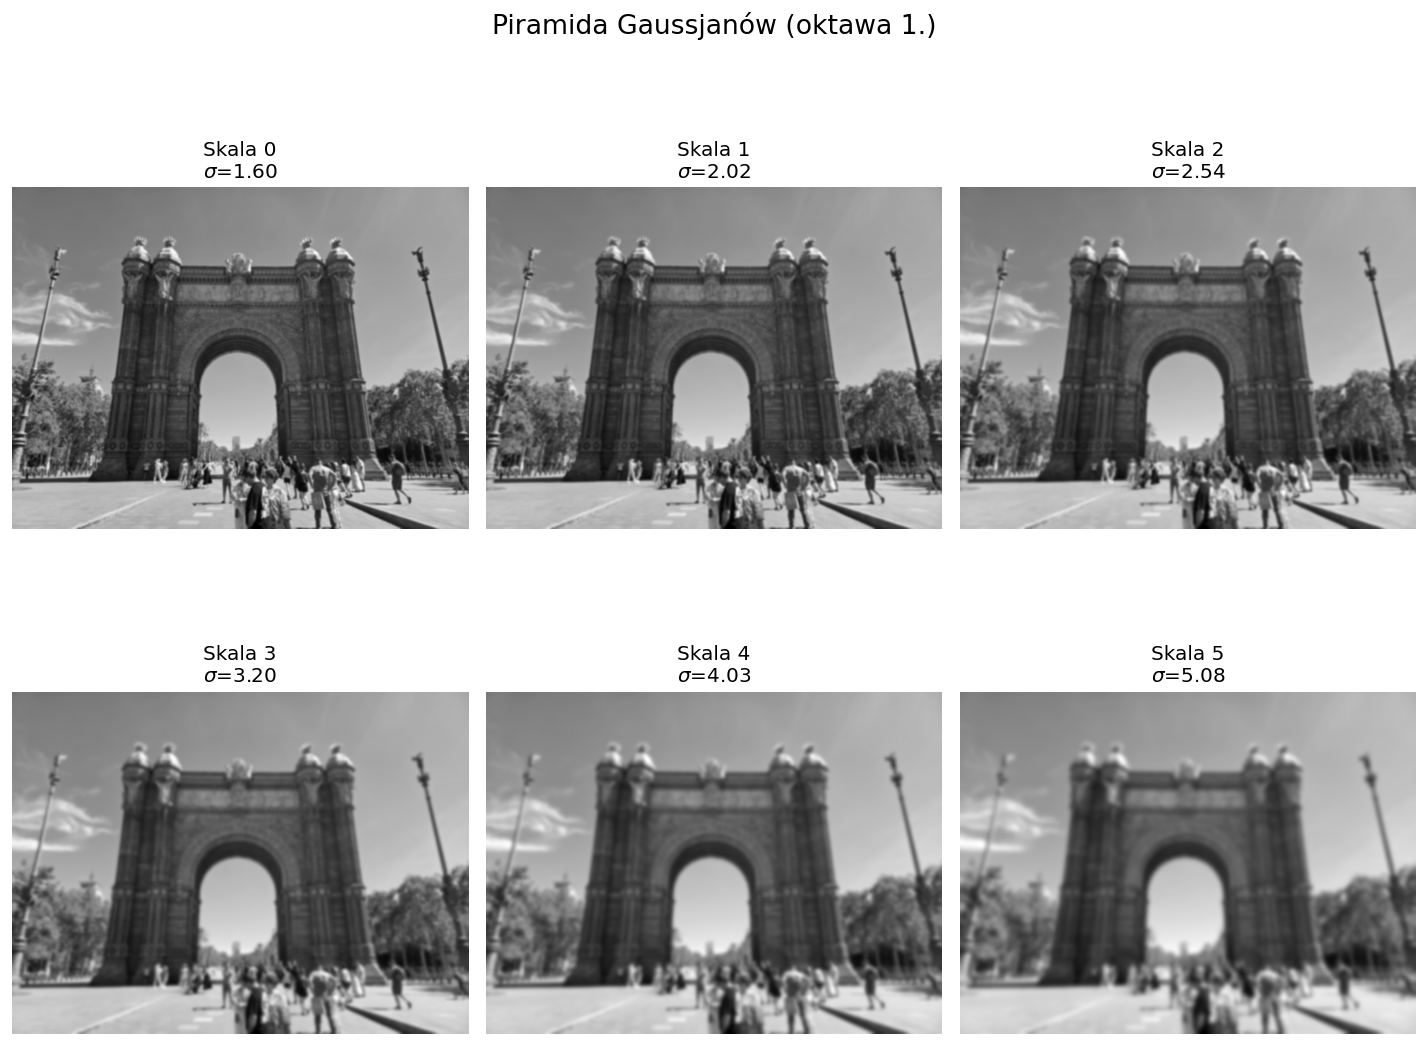

In [4]:
# USTAW WŁASNE WARTOŚCI - domyślne zgodne z artykułem Lowe
# liczba interwałów - określa, ile znaczących poziomów skali będzie w oktawie
NO_OF_SCALES = 3
# bazowy współczynnik rozmycia
SIGMA_BASE = 1.6

images_per_octave = NO_OF_SCALES + 3
k = 2 ** (1.0 / NO_OF_SCALES)

gaussian_pyramid = []
titles_gauss = []

for i in range(images_per_octave):
    current_sigma = k ** i * SIGMA_BASE
    blurred = cv2.GaussianBlur(image_gray, (0, 0), sigmaX=current_sigma, sigmaY=current_sigma)

    gaussian_pyramid.append(blurred)
    titles_gauss.append(f"Skala {i}\n$\\sigma$={current_sigma:.2f}")

# wizualizacja
n_cols = 3
n_rows = (images_per_octave + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows), dpi=120)
for ax, img_layer, title in zip(axes.ravel(), gaussian_pyramid, titles_gauss):
    ax.imshow(img_layer, cmap='gray')
    ax.set_title(title, fontsize=12)
    ax.axis('off')
for ax in axes.ravel()[images_per_octave:]:
    ax.axis('off')
plt.suptitle("Piramida Gaussjanów (oktawa 1.)", fontsize=16)
plt.tight_layout()
plt.show()

#### Krok 3. Wyznaczenie różnicy Gaussjanów (Difference of Gaussians - DoG)

W celu efektywnego wykrycia punktów charakterystycznych odejmujemy od siebie sąsiadujące ze sobą obrazy z utworzonej przed chwilą piramidy Gaussjanów. Dla 6 obrazów w oktawie otrzymamy 5 obrazów różnicowe.

Operacja ta działa jak zaawansowany filtr krawędziowy (przybliżenie Laplasjanu Gaussa). Usuwa ona obszary o jednolitej jasności, a uwypukla miejsca, w których następuje gwałtowna zmiana tekstury (rogi, krawędzie, plamy).

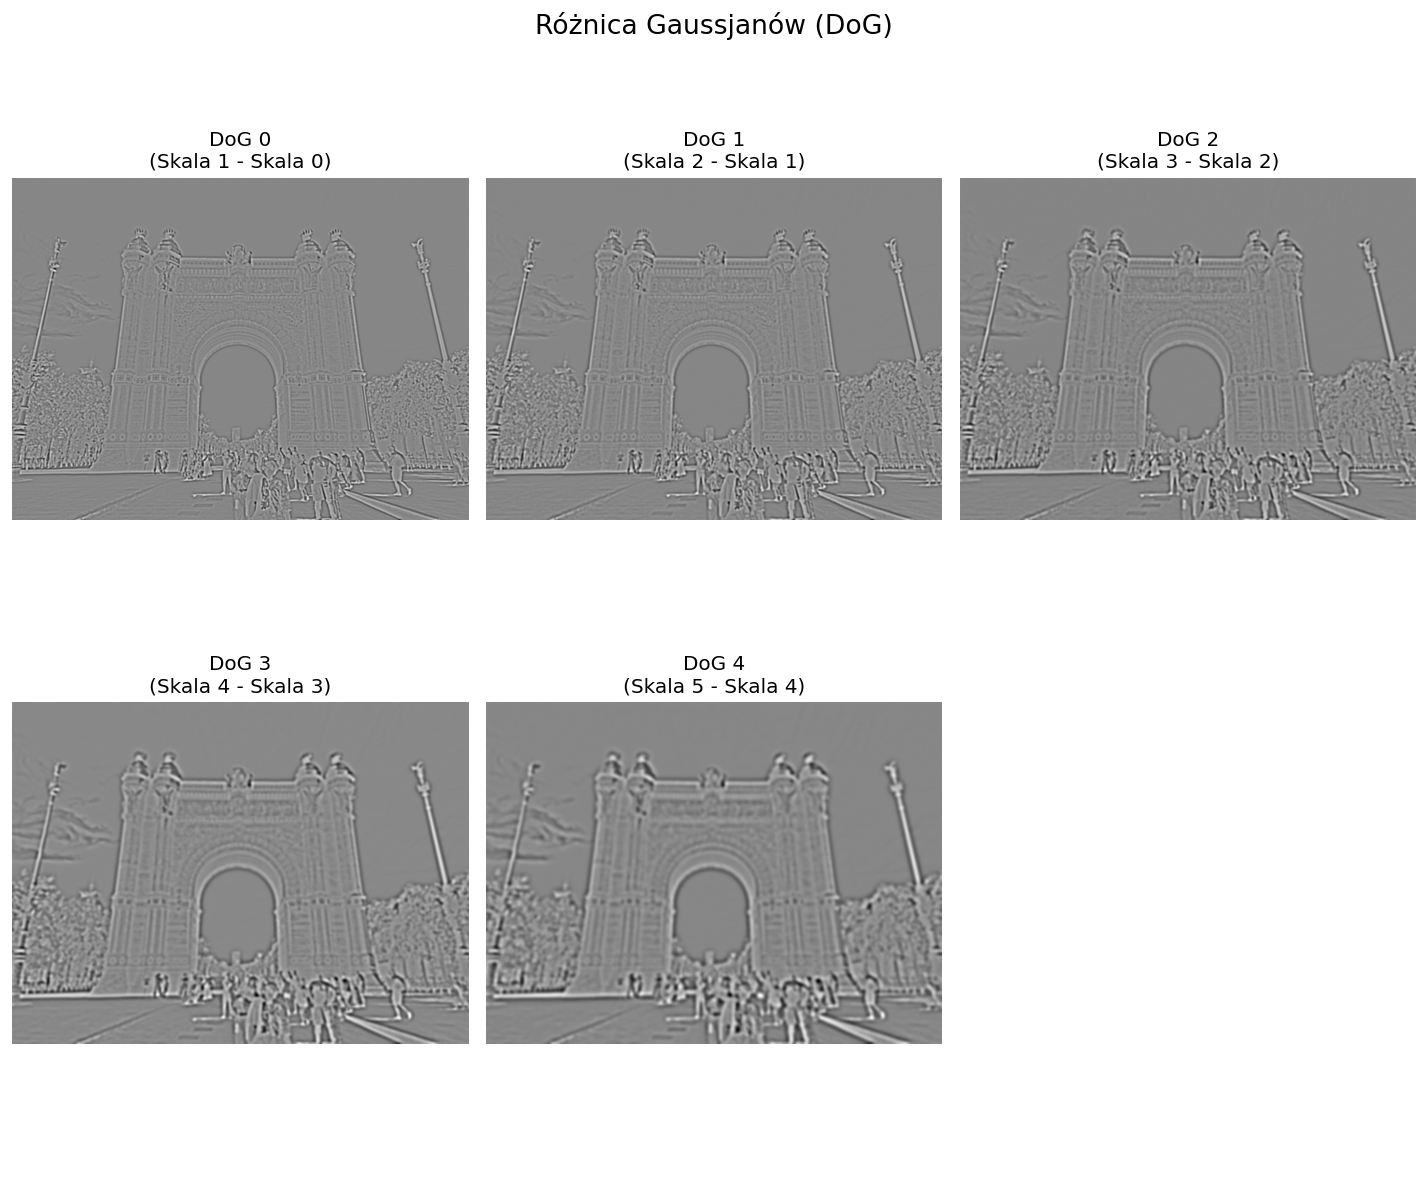

In [5]:
dog_pyramid = []
titles_dog = []

for i in range(images_per_octave - 1):
    dog = cv2.subtract(gaussian_pyramid[i + 1], gaussian_pyramid[i])
    dog_pyramid.append(dog)
    titles_dog.append(f"DoG {i}\n(Skala {i + 1} - Skala {i})")

# wizualizacja
n_cols = 3
n_rows = (len(dog_pyramid) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows), dpi=120)
for ax, dog_layer, title in zip(axes.ravel(), dog_pyramid, titles_dog):
    ax.imshow(dog_layer, cmap='gray')
    ax.set_title(title, fontsize=12)
    ax.axis('off')
for ax in axes.ravel()[len(dog_pyramid):]:
    ax.axis('off')
plt.suptitle("Różnica Gaussjanów (DoG)", fontsize=16)
plt.tight_layout()
plt.show()

#### Krok 4. Detekcja potencjalnych punktów charakterystycznych (ekstrema przestrzeni skali)

Aby punkt mógł zostać uznany za lokalną cechę (niewrażliwą na zmianę skali), musi być lokalnym ekstremum nie tylko na swoim obrazie, ale również w wymiarze skali.

Pojedynczy piksel na wybranym poziomie (np. `DoG 1`) jest porównywany z **26 sąsiadami**:
* **8** najbliższych sąsiadów na tym samym poziomie (`DoG 1`),
* **9** sąsiadów na poziomie poniżej (`DoG 0`),
* **9** sąsiadów na poziomie powyżej (`DoG 2`).

Poniżej została wykonana detekcja ekstremów wyłącznie w obrazie różnicowym `DoG 1`, odrzucając przy tym punkty o zbyt niskim kontraście, które mogłyby zostać uznane za szum. Wyniki nanosimy na oryginalny kolorowy obraz.

Liczba wykrytych stabilnych punktów charakterystycznych na poziomie DoG 1: 289


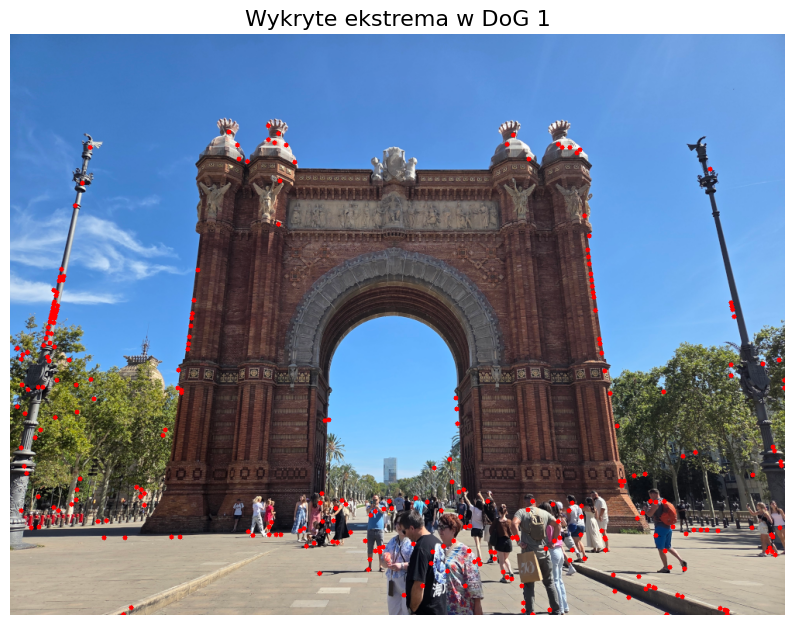

In [6]:
# USTAW WŁASNE WARTOŚCI
# próg kontrastu
CONTRAST_THRESHOLD = 0.03

from scipy.ndimage import maximum_filter, minimum_filter

dog_stack = np.stack(dog_pyramid[0:3], axis=-1)

is_max = maximum_filter(dog_stack, size=(3, 3, 3)) == dog_stack
is_min = minimum_filter(dog_stack, size=(3, 3, 3)) == dog_stack
is_extrema = is_max | is_min

current_image_idx = 1

extrema_mask = is_extrema[:, :, current_image_idx]
stability_mask = np.abs(dog_pyramid[current_image_idx]) > CONTRAST_THRESHOLD

final_mask = extrema_mask & stability_mask

y_coords, x_coords = np.where(final_mask)

print(f"Liczba wykrytych stabilnych punktów charakterystycznych na poziomie DoG 1: {len(y_coords)}")

# wizualizacja
output_img = image.copy()

for y, x in zip(y_coords, x_coords):
    cv2.circle(output_img, (x, y), radius=3, color=(0, 0, 255), thickness=-1)

show_img(output_img, title="Wykryte ekstrema w DoG 1", figsize=(10, 8))

#### Krok 5. Eliminacja punktów na krawędziach

Mamy teraz listę potencjalnych punktów kluczowych, ale nie wszystkie są stabilne. Punkty leżące na prostych krawędziach są złymi kandydatami. Możemy wyobrazić sobie kropkę na linii prostej - jeśli przesuniesz ją nieznacznie wzdłuż tej linii, otoczenie będzie wyglądać identycznie. To utrudnia dopasowanie.

SIFT rozwiązuje ten problem, analizując macierz Hessego w każdym wykrytym punkcie na poziomie DoG. Macierz ta opisuje krzywiznę obrazu w dwóch prostopadłych kierunkach. 

Jeżeli stosunek większej krzywizny do mniejszej jest zbyt duży (co oznacza, że mamy do czynienia z krawędzią, a nie z narożnikiem lub "plamką"), punkt jest odrzucany. W tym celu obliczamy Ślad (Trace) i Wyznacznik (Determinant) macierzy Hessiana.

In [ ]:
# Pracujemy na warstwie DoG 1, gdzie znaleźliśmy kandydatów
dog_image = dog_pyramid[center_layer_idx]

# Obliczamy pochodne cząstkowe rzędu drugiego (Hessian) za pomocą filtru Sobela
# cv2.Sobel oczekuje formatu, który może przechowywać wartości ujemne (np. cv2.CV_64F)
dxx = cv2.Sobel(dog_image, cv2.CV_64F, 2, 0, ksize=3)
dyy = cv2.Sobel(dog_image, cv2.CV_64F, 0, 2, ksize=3)
dxy = cv2.Sobel(dog_image, cv2.CV_64F, 1, 1, ksize=3)

# Parametr r z pracy D. Lowe'a (często ustawiany na 10). 
# Próg eliminuje punkty, których stosunek krzywizn > (r+1)^2 / r
r = 10
threshold_edge = ((r + 1.0) ** 2) / r

filtered_y = []
filtered_x = []
rejected_y = []
rejected_x = []

# Analizujemy każdego z kandydujących punktów
for y, x in zip(y_coords, x_coords):
    # Pomijamy punkty zbyt blisko krawędzi obrazu (brak pełnego sąsiedztwa 3x3)
    if y == 0 or y == dog_image.shape[0] - 1 or x == 0 or x == dog_image.shape[1] - 1:
        continue

    # Pobieramy wartości drugich pochodnych dla danego punktu
    Dxx, Dyy, Dxy = dxx[y, x], dyy[y, x], dxy[y, x]

    # Obliczamy Ślad (Trace) i Wyznacznik (Determinant) macierzy Hessiana
    # H = [[Dxx, Dxy], 
    #      [Dxy, Dyy]]
    tr = Dxx + Dyy
    det = (Dxx * Dyy) - (Dxy ** 2)

    # Odrzucamy punkty z ujemnym wyznacznikiem (krzywizny mają różne znaki)
    if det > 0:
        score = (tr ** 2) / det
        # Jeśli stosunek krzywizn jest mniejszy niż próg, punkt ZOSTANE
        if score < threshold_edge:
            filtered_y.append(y)
            filtered_x.append(x)
        else:
            rejected_y.append(y)
            rejected_x.append(x)
    else:
        rejected_y.append(y)
        rejected_x.append(x)

print(f"Punkty przed filtracją krawędzi: {len(y_coords)}")
print(f"Punkty po filtracji krawędzi: {len(filtered_y)}")
print(f"Odrzucono: {len(y_coords) - len(filtered_y)} punktów ({(1 - len(filtered_y) / len(y_coords)) * 100:.1f}%)")

# Wizualizacja ocalałych, stabilnych punktów
output_img_filtered = img1_bgr.copy()
for y, x in zip(filtered_y, filtered_x):
    cv2.circle(output_img_filtered, (x, y), radius=3, color=(0, 255, 0), thickness=-1)

for y, x in zip(rejected_y, rejected_x):
    cv2.circle(output_img_filtered, (x, y), radius=3, color=(0, 0, 255), thickness=-1)

show_img(output_img_filtered, title="Stabilne punkty zielone, odrzucone czerwone", figsize=(10, 8))

#### Krok 6: Odporność na rotację

Mamy już wybrane stabilne punkty (odporne na zmianę skali i przesunięcie wzdłuż krawędzi). Teraz musimy sprawić, by były odporne na obrót.

Algorytm analizuje obszar wokół każdego punktu kluczowego na odpowiednio rozmytym obrazie z piramidy Gaussa. Dla każdego piksela w tym otoczeniu oblicza moduł i kąt gradientu jasności. Następnie tworzy histogram kierunków (najczęściej 36 koszyków po 10 stopni). Kierunek, który zbierze najwięcej "głosów" (czyli dominujący spadek jasności w okolicy), staje się główną orientacją punktu. 

Od tej pory SIFT będzie opisywał ten punkt tak, jakby obraz był "zawsze obrócony" w tę dominującą stronę.

In [ ]:
# Aby to zwizualizować krok po kroku (tworzenie histogramu koszykowego wokół punktu), 
# potrzebujemy obliczyć moduł i kąt gradientu dla obrazu Gaussa.
# Użyjemy warstwy Gaussa o indeksie 1, która odpowiada naszemu DoG 1.
gaussian_layer = gaussian_pyramid[1]

# Obliczamy gradienty w osiach X i Y (używając Sobela, tak jak radził Lowe)
gx = cv2.Sobel(gaussian_layer, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(gaussian_layer, cv2.CV_64F, 0, 1, ksize=3)

# Funkcja cv2.cartToPolar błyskawicznie konwertuje x,y na moduł(siłę) i kąt (w radianach)
magnitude, angle = cv2.cartToPolar(gx, gy, angleInDegrees=True)

# Pokażmy rozkład gradientów wokół PIERWSZEGO wybranego punktu z listy
# Wybieramy okno 16x16 pikseli wokół punktu
pt_y, pt_x = filtered_y[0], filtered_x[0]
radius = 8  # połowa rozmiaru okna

# Zabezpieczenie przed krawędziami obrazu
if pt_y - radius > 0 and pt_y + radius < gaussian_layer.shape[0] and \
        pt_x - radius > 0 and pt_x + radius < gaussian_layer.shape[1]:
    # Wycinek modułu i kąta dla okna wokół punktu
    mag_window = magnitude[pt_y - radius: pt_y + radius, pt_x - radius: pt_x + radius]
    ang_window = angle[pt_y - radius: pt_y + radius, pt_x - radius: pt_x + radius]

    # Tworzymy histogram 36 koszyków (360 stopni / 10)
    hist, bins = np.histogram(ang_window.flatten(), bins=36, range=(0, 360), weights=mag_window.flatten())

    # Znajdujemy koszyk o największej wartości (dominujący kierunek)
    dominant_angle_bin = np.argmax(hist)
    dominant_angle = bins[dominant_angle_bin]

    print(f"Analizujemy punkt (X:{pt_x}, Y:{pt_y})")
    print(f"Dominujący kąt gradientu: {dominant_angle:.1f}°")

    # Szersze otoczenie (wycinek ok. 200x200 pikseli wokół punktu)
    ctx_radius = 100
    y_start = max(0, pt_y - ctx_radius)
    y_end = min(gaussian_layer.shape[0], pt_y + ctx_radius)
    x_start = max(0, pt_x - ctx_radius)
    x_end = min(gaussian_layer.shape[1], pt_x + ctx_radius)

    plt.figure(figsize=(5, 5))
    plt.imshow(gaussian_layer[y_start:y_end, x_start:x_end], cmap='gray')
    plt.plot(pt_x - x_start, pt_y - y_start, 'ro', markersize=5)  # Punkt na wycinku
    plt.title("Szersze otoczenie punktu (~200x200)")
    plt.axis('off')
    plt.show()

    # Zoom na okno 16x16 z wektorem orientacji
    plt.figure(figsize=(4, 4))
    plt.imshow(gaussian_layer[pt_y - radius: pt_y + radius, pt_x - radius: pt_x + radius], cmap='gray')
    plt.plot(radius, radius, 'ro', markersize=5)

    # Rysowanie strzałki orientacji (długość strzałki to np. 5 pikseli)
    arrow_len = 5
    dx = arrow_len * np.cos(np.deg2rad(dominant_angle))
    dy = arrow_len * np.sin(np.deg2rad(dominant_angle))
    plt.arrow(radius, radius, dx, dy, color='red', head_width=0.8, head_length=1.2)

    plt.title("Zoom na okno 16x16 z orientacją")
    plt.axis('off')
    plt.show()

    # Wizualizacja Histogramu
    plt.figure(figsize=(10, 4))
    plt.bar(bins[:-1], hist, width=10, align='edge', color='orange', edgecolor='black')
    plt.axvline(dominant_angle, color='red', linestyle='dashed', linewidth=2,
                label=f'Główna orientacja ({dominant_angle:.1f}°)')
    plt.title("Histogram kierunków gradientu dla pojedynczego punktu")
    plt.xlabel("Kąt (Stopnie)")
    plt.ylabel("Siła (suma modułów gradientu)")
    plt.legend()
    plt.show()

#### Krok 7: Podsumowanie (Wizualizacja z OpenCV)

Aby wygenerować ostateczny deskryptor, wokół punktu tworzy się siatkę 4x4. W każdym z 16 podregionów liczony jest osobny histogram kierunków (8 koszyków). Daje to 16 * 8 = **128-wymiarowy wektor**.

Zamiast pisać ten żmudny, czysto optymalizacyjny proces od zera, wykorzystajmy teraz wbudowaną implementację SIFT z OpenCV. 

**Co ważne:** Skonfigurujemy funkcję w OpenCV tak, aby używała **dokładnie tych samych parametrów**, których użyliśmy w naszych ręcznych krokach:
* `sigma = 1.6` (z Kroku 2)
* Próg kontrastu = `0.03` (z Kroku 4)
* Próg krawędzi (Hessian) r = `10` (z Kroku 5)

*Uwaga:* Nasz ręczny kod analizował tylko jedną, bazową **oktawę** (jeden rozmiar obrazu). OpenCV automatycznie przeskaluje obraz wiele razy, tworząc pełną wielopoziomową piramidę. Dlatego znajdzie więcej punktów kluczowych niż nasz skrypt, ale użyje do tego naszych zasad filtracji!

In [ ]:
# Konwertujemy nasz zmiennoprzecinkowy obraz na format 8-bitowy (oczekiwany przez bibliotekę)
img1_8bit = (img1_gray * 255).astype(np.uint8)

# Inicjalizacja zoptymalizowanego algorytmu OpenCV z NASZYMI parametrami z poprzednich komórek!
sift_custom = cv2.SIFT_create(
    nfeatures=1000,  # 0 = brak limitu, szukamy wszystkich punktów
    nOctaveLayers=3,  # Ilość warstw z ekstremami (wymusza 5 obrazów Gaussa, tak jak u nas)
    contrastThreshold=0.03,  # Nasz próg szumu z Kroku 3
    edgeThreshold=10,  # Nasz próg krawędziowy 'r' z Kroku 4
    sigma=1.6  # Nasze bazowe rozmycie z Kroku 1
)

# Wykrywamy ekstrema i obliczamy deskryptory (te 128-elementowe wektory)
keypoints_cv, descriptors_cv = sift_custom.detectAndCompute(img1_8bit, None)

# Rysujemy wyniki
# Używamy flagi DRAW_RICH_KEYPOINTS, aby narysować okręgi pokazujące SKALĘ oraz ORIENTACJĘ
final_img = cv2.drawKeypoints(
    img1_bgr,
    keypoints_cv,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
    color=(0, 0, 255)
)

show_img(final_img, title=f"Wynik końcowy (OpenCV): {len(keypoints_cv)} punktów z naszymi parametrami",
         figsize=(12, 10))

### SIFT playground

In [ ]:
import io
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

np.random.seed(42)
num_points = 60

# --- 1. Generowanie danych dla pierwszego obrazu ---
# Punkty rozmieszczone w kwadracie 10x10
pts1_x = np.random.uniform(0, 10, num_points)
pts1_y = np.random.uniform(0, 10, num_points)

# --- 2. Generowanie danych dla różnych wariantów drugiego obrazu ---
datasets = {}


def generate_mock_data(scenario):
    # Symulacja odległości deskryptorów dla danego zestawu
    d1 = np.random.uniform(20, 85, num_points)
    ratios = np.random.uniform(0.4, 0.95, num_points)
    d2 = d1 / ratios

    if scenario == 'Standard vs Scaled':
        # Punkty "skurczone" bliżej środka
        p2_x = pts1_x * 0.7 + 1.5
        p2_y = pts1_y * 0.7 + 1.5
    elif scenario == 'Standard vs Rotated':
        # Punkty obrócone o 25 stopni względem środka kwadratu
        theta = np.radians(25)
        c, s = np.cos(theta), np.sin(theta)
        cx, cy = 5, 5  # Środek obrotu
        p2_x = cx + c * (pts1_x - cx) - s * (pts1_y - cy)
        p2_y = cy + s * (pts1_x - cx) + c * (pts1_y - cy)
    elif scenario == 'Standard vs Occluded':
        # Punkty nieco przesunięte, ale z symulacją "braku dopasowania" (okluzja)
        p2_x = pts1_x + np.random.normal(0, 0.3, num_points)
        p2_y = pts1_y + np.random.normal(0, 0.3, num_points)
        # Sztucznie zawyżamy odległość d1 dla co 3-go punktu, żeby "wypadł" z limitu odległości
        d1[::3] = 150

        # Przesuwamy drugi obraz na osi X o 15 jednostek w prawo, żeby nie nakładał się na pierwszy
    p2_x += 15
    return p2_x, p2_y, d1, d2


# Inicjalizacja trzech zestawów danych
datasets['Standard vs Scaled'] = generate_mock_data('Standard vs Scaled')
datasets['Standard vs Rotated'] = generate_mock_data('Standard vs Rotated')
datasets['Standard vs Occluded'] = generate_mock_data('Standard vs Occluded')

img_widget = widgets.Image(format='png')


# --- 3. Funkcja rysująca wykres ---
def plot_sift_simulation(ratio_threshold, distance_limit, dataset_name):
    fig, ax = plt.subplots(figsize=(12, 6))

    # Pobranie danych dla wybranego wariantu
    pts2_x, pts2_y, d1, d2 = datasets[dataset_name]

    # Rysowanie przerywanych KWADRATÓW (obszary 10x10)
    # Lewy kwadrat (obraz 1)
    ax.plot([-1, 11, 11, -1, -1], [-1, -1, 11, 11, -1], 'k--', alpha=0.3)
    # Prawy kwadrat (obraz 2 - przesunięty o 15 w prawo na osi X)
    ax.plot([14, 26, 26, 14, 14], [-1, -1, 11, 11, -1], 'k--', alpha=0.3)

    # Punkty
    ax.scatter(pts1_x, pts1_y, c='#74b9ff', s=40, zorder=5, edgecolors='black')
    ax.scatter(pts2_x, pts2_y, c='#55efc4', s=40, zorder=5, edgecolors='black')

    matches_found = 0
    false_positives = 0

    # Rysowanie linii dopasowań
    for i in range(num_points):
        if d1[i] < distance_limit:
            if (d1[i] / d2[i]) < ratio_threshold:
                # Test ZDANY (zielona linia)
                ax.plot([pts1_x[i], pts2_x[i]], [pts1_y[i], pts2_y[i]],
                        c='#2ecc71', alpha=0.7, linewidth=2, zorder=1)
                matches_found += 1
            else:
                # Test OBLANY (czerwona linia)
                ax.plot([pts1_x[i], pts2_x[i]], [pts1_y[i], pts2_y[i]],
                        c='#e74c3c', alpha=0.4, linewidth=1.5, zorder=1)
                false_positives += 1

    ax.set_title(f"Matches Found (Passed): {matches_found}   |   False Positives (Ambiguous): {false_positives}",
                 fontsize=14, fontweight='bold', pad=20)

    ax.set_aspect('equal', adjustable='box')
    ax.axis('off')

    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    img_widget.value = buf.read()


# --- 4. Interfejs Użytkownika ---
style = {'description_width': 'initial'}

dataset_dropdown = widgets.Dropdown(
    options=['Standard vs Scaled', 'Standard vs Rotated', 'Standard vs Occluded'],
    value='Standard vs Scaled',
    description='Image Pair:',
    style=style
)

ratio_slider = widgets.FloatSlider(
    value=0.70, min=0.1, max=1.0, step=0.01,
    description="Lowe's Ratio:",
    layout=widgets.Layout(width='350px'), style=style
)

distance_slider = widgets.IntSlider(
    value=65, min=10, max=100, step=1,
    description='Descriptor Distance Limit:',
    layout=widgets.Layout(width='350px'), style=style
)

ui = widgets.VBox([
    dataset_dropdown,
    widgets.HBox([ratio_slider, distance_slider], layout=widgets.Layout(margin='10px 0px 0px 0px'))
])


# Definiujemy funkcję, która aktualizuje wykres wewnątrz widgetu Output
def update_plot(change):
    plot_sift_simulation(ratio_slider.value, distance_slider.value, dataset_dropdown.value)


# Podpinamy funkcję pod zdarzenie zmiany wartości na suwakach/liście
dataset_dropdown.observe(update_plot, names='value')
ratio_slider.observe(update_plot, names='value')
distance_slider.observe(update_plot, names='value')

# Wymuszamy pierwsze narysowanie wykresu przy uruchomieniu komórki
update_plot(None)

# Wyświetlamy całość
display(ui, img_widget)

### Opis implementacji

Nasza implementacja tworzy otoczkę wokół struktur udostępnianych przez bibliotekę `OpenCV` w celu zapewnienia prostej konfiguracji i jednolitego interfejsu. Udostępnione zostają dwie główne klasy:

- Klasa `SiftConfig` umożliwia na skonfigurowanie sposobu dopasowywania punktów charakterystycznych między obrazami. Pozwala m.in. zastosowanie testu Lowe'a do odrzucania fałszywych dopasowań lub na wybór typu matchera - Brute-Force (_BFMatcher_) lub _FLANN_ (szybszy dla dużych obrazów).
- Klasa `SiftMatcher` udostępnia metody umożliwiające proste wykonanie całego procesu od załadowania obrazów, przez ekstrakcję lokalnych cech, aż po porównanie cech obrazów i wizualizację dopasowań.

Zostały one przygotowane poniżej:

In [ ]:
from enum import Enum

import cv2
import matplotlib.pyplot as plt
import numpy as np

from dataclasses import dataclass
from typing import Optional, Dict, Any


class SiftMatcherType(Enum):
    BFMatcher = 1
    FLANN = 2


@dataclass
class SiftConfig:
    """Configuration parameters for SIFT matcher."""
    matcher_type: SiftMatcherType = SiftMatcherType.BFMatcher
    norm_type: int = cv2.NORM_L2  # cv2.NORM_L2 / cv2.NORM_L1
    ratio_threshold: float = 0.75  # Lowe test threshold
    cross_check: bool = False  # BFMatcher flag ( (wzajemnie najlepsze dopasowania)
    flann_index_params: Optional[Dict[str, Any]] = None
    flann_search_params: Optional[Dict[str, Any]] = None

    def __post_init__(self):
        """Initialize FLANN params."""
        if self.matcher_type == SiftMatcherType.FLANN:
            FLANN_INDEX_KDTREE = 1
            if self.flann_index_params is None:
                self.flann_index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
            if self.flann_search_params is None:
                self.flann_search_params = dict(checks=50)


class SiftMatcher:

    def __init__(self, config: SiftConfig = SiftConfig()):
        self.sift = cv2.SIFT_create()
        self.config = config
        self.matcher = cv2.BFMatcher(cv2.NORM_L2)

        if self.config.matcher_type == SiftMatcherType.BFMatcher:
            self.matcher = cv2.BFMatcher(
                normType=self.config.norm_type,
                crossCheck=self.config.cross_check
            )
        elif self.config.matcher_type == SiftMatcherType.FLANN:
            self.matcher = cv2.FlannBasedMatcher(
                self.config.flann_index_params,
                self.config.flann_search_params
            )
        else:
            raise ValueError('Unknown SIFT matcher.')

    @staticmethod
    def load_image(path: str) -> np.ndarray:
        """
        Loads image from path.
        :param path: Path to image
        :return: Loaded image
        """
        img = cv2.imread(path)
        if img is None:
            raise FileNotFoundError(f"Failed to load image: {path}")
        return img

    def extract_features(self, image: np.ndarray):
        """
        Extracts feature points and their descriptors from the image.
        :param image: Image to extract features from
        :return: Tuple of keypoints and descriptors
        """
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        keypoints, descriptors = self.sift.detectAndCompute(gray, None)
        return keypoints, descriptors

    @staticmethod
    def draw_features(image: np.ndarray, keypoints: list, rich_display: bool = False) -> np.ndarray:
        """
        Draws local features onto the image.
        :param image: Source image with extracted features
        :param keypoints: Key points of the image
        :param rich_display: Indicates whether to display additional details, such as orientation
        :return: Image with drawn local features
        """
        flag = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS if rich_display else cv2.DRAW_MATCHES_FLAGS_DEFAULT

        result_image = cv2.drawKeypoints(
            image,
            keypoints,
            None,
            color=(0, 0, 255),
            flags=flag
        )
        return result_image

    def find_matches(self, descriptors1: np.ndarray, descriptors2: np.ndarray) -> list:
        """
        Discovers best feature matches using configured matcher.
        :param descriptors1: Descriptors of the first image features
        :param descriptors2: Descriptors of the second image features
        :return: Matching feature points
        """
        if self.config.matcher_type == SiftMatcherType.BFMatcher and self.config.cross_check:
            raw_matches = self.matcher.match(descriptors1, descriptors2)
            good_matches = sorted(raw_matches, key=lambda x: x.distance)
        else:
            # KNN + Lowe test
            raw_matches = self.matcher.knnMatch(descriptors1, descriptors2, k=2)
            good_matches = []

            for m, n in raw_matches:
                if m.distance < self.config.ratio_threshold * n.distance:
                    good_matches.append(m)

        return good_matches

    @staticmethod
    def draw_matches(img1, kp1, img2, kp2, matches) -> np.ndarray:
        """
        Draws lines between matching feature points between 2 images.
        :param img1: First image
        :param kp1: Feature points of the first image
        :param img2: Second image
        :param kp2: Feature points of the second image
        :param matches: Matching features
        :return: Image stitch with matches
        """

        result_image = cv2.drawMatches(
            img1, kp1, img2, kp2, matches, None,
            matchColor=(0, 255, 0),
            singlePointColor=None,
            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
        )
        return result_image

    @staticmethod
    def show_image(title: str, image: np.ndarray):
        """
        Displays image on screen.
        :param title: Title of image
        :param image: Image to display
        """
        img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(15, 10))
        plt.title(title)
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.show()


### Prezentacja wyników działania
Zaczniemy od przedstawienia detekcji lokalnych cech obrazu. Po wczytaniu obrazu wyznaczamy jego punkty charakterystyczne i zwizualizujemy je na tym samym obrazie:

In [ ]:
matcher_config = SiftConfig()  # BFMatcher with 0.75 Lowe threshold by default
sift = SiftMatcher(matcher_config)

In [ ]:
IMAGE_PATH = 'set2/ref.png'  # replace with valid file path to your image
image1 = SiftMatcher.load_image(IMAGE_PATH)

features1, descriptors1 = sift.extract_features(image1)
image_with_features = SiftMatcher.draw_features(image1, features1, rich_display=True)

SiftMatcher.show_image('SIFT - detekcja punktów charakterystycznych', image_with_features)

Punkty charakterystyczne zostały zaznaczone na obrazie za pomocą czerwonych obręczy przedstawiających również wielkość oraz orientację punktów, co jest możliwe dzięki zastosowaniu parametru `rich_display`.

---

Następnie przedstawimy przykład dopasowania punktów między dwoma obrazami. W tym celu dokonamy ekstrakcji cech w drugim obrazie i wyszukamy odpowiednie dopasowania między obrazami (tylko 1000 dopasowań dla lepszej widoczności):

In [ ]:
IMAGE_PATH = 'set2/mod.png'  # replace with valid file path to your image
image2 = SiftMatcher.load_image(IMAGE_PATH)

features2, descriptors2 = sift.extract_features(image2)
image_with_features = SiftMatcher.draw_features(image2, features2, rich_display=True)

SiftMatcher.show_image('SIFT - obraz drugi z cechami', image_with_features)

In [ ]:
good_matches = sift.find_matches(descriptors1, descriptors2)
comparison_image = SiftMatcher.draw_matches(image1, features1, image2, features2, good_matches[:1000])

SiftMatcher.show_image('SIFT - dopasowania między obrazami', comparison_image)

### Weryfikacja eksperymentalna